In [17]:
#Import all libraries   
#Data Manipulation
import pandas as pd

#Numerical Computing
import numpy as np  

import math                       

#Numerical & Scientific Computing                
from scipy import stats             
from scipy.stats import pearsonr    

#Visualisation 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

#Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 6)

#Machine Learning 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                                      confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TOPIC 2: DATA TYPES & DECLARATIONS                         ║
# ╚══════════════════════════════════════════════════════════════╝

# --- Integer (int) ---
n_estimators: int = 100          # Number of trees in Random Forest
random_state: int = 42           # Seed for reproducibility
max_depth: int = 10              # Maximum tree depth
n_folds: int = 5                 # Cross-validation folds

# --- Floating-point (float) ---
test_size: float = 0.20          # 20% of data reserved for testing
learning_rate: float = 0.01      # Logistic regression step size
threshold: float = 0.80          # Minimum acceptable accuracy (80%)

# --- String (str) ---
project_title: str = "Student Grade Prediction System"
course_code:   str = "SMA 390"
target_column: str = "grade"
csv_path:      str = "student_performance.csv"

# --- Boolean (bool) ---
use_scaling:      bool = True     # Apply StandardScaler for Logistic Regression
stratify_split:   bool = True     # Maintain grade proportions in train/test split
remove_duplicates: bool = True

# --- List (list) ---
feature_columns: list = [
    'weekly_self_study_hours',
    'attendance_percentage',
    'class_participation',
    'total_score'
]
grade_order: list = ['A', 'B', 'C', 'D', 'F']  # Ordered grade labels

# --- Tuple (tuple) ---  immutable – cannot be modified after creation
grade_colors: tuple = ('#2ECC71', '#3498DB', '#F39C12', '#E67E22', '#E74C3C')
figure_size: tuple = (14, 6)     # Width × height in inches

# --- Dictionary (dict) ---
model_params: dict = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'random_state': random_state,
    'n_jobs': -1                  # Use all CPU cores
}
grade_descriptions: dict = {
    'A': 'Excellent (75–100%)',
    'B': 'Good (60–74%)',
    'C': 'Average (50–59%)',
    'D': 'Below Average (40–49%)',
    'F': 'Fail (0–39%)'
}

# --- NumPy ndarray (numpy.ndarray) ---
sample_scores: np.ndarray = np.array([97.9, 83.9, 100.0, 100.0, 92.0])
grade_weights: np.ndarray = np.array([0.30, 0.25, 0.25, 0.20])  # Feature importance priors

print(f'Project : {project_title} | Course: {course_code}')
print(f'Features: {feature_columns}')
print(f'Model params: {model_params}')
print(f'Sample scores array (ndarray): {sample_scores}')
print(f'Array mean: {sample_scores.mean():.2f} | std: {sample_scores.std():.2f}')
print(f'\n✅ All data types declared and verified.')

Project : Student Grade Prediction System | Course: SMA 390
Features: ['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']
Model params: {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}
Sample scores array (ndarray): [ 97.9  83.9 100.  100.   92. ]
Array mean: 94.76 | std: 6.17

✅ All data types declared and verified.


---
## Phase 1: Business Understanding

### Problem Statement
Educational institutions face the challenge of identifying at-risk students **before** end-of-semester examinations. By predicting a student's final grade from observable academic behaviours, this system enables early intervention.

### Objectives
1. Predict a student's final grade (A, B, C, D, or F) from four input features.
2. Identify which features most influence student performance.
3. Compare three classifiers: Logistic Regression, Decision Tree and Random Forest.
4. Deploy an interactive prediction function for real-time use.

### Success Criterion
Test-set accuracy ≥ **80%** and stable 5-fold cross-validation performance.

### Mathematical Notation (

Let the feature vector for student *i* be:

$$\mathbf{x}_i = [x_1, x_2, x_3, x_4]^T$$

where $x_1$ = weekly study hours, $x_2$ = attendance %, $x_3$ = participation score, $x_4$ = total score.

The prediction model maps $\mathbf{x}_i \rightarrow \hat{y}_i \in \{A, B, C, D, F\}$.

Classification accuracy is defined as:
$$\text{Accuracy} = \frac{\sum_{i=1}^{n} \mathbb{1}[\hat{y}_i = y_i]}{n}$$

---
## Phase 2: Data Understanding

In [19]:
#Load dataset 
df = pd.read_csv(r"student_performance.csv")
                 

In [20]:
#Get metadata
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 46.7 MB


In [21]:
#check nulls
print(f" The datset has {df.isnull().sum().sum()} null values.")

 The datset has 0 null values.


In [22]:
#Check for duplicates
print(f" The dataset has {df.duplicated().sum()} duplicate rows.")

 The dataset has 0 duplicate rows.


In [23]:
#Statistical summary
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278932,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


In [24]:
# Count grades
grade_counts = {}

for grade in grade_order:
    count = (df['grade'] == grade).sum()
    grade_counts[grade] = count

    percentage = count / len(df) * 100
    print(f"Grade {grade}: {count} students ({percentage:.1f}%)")

# Check if dataset is balanced
total_students = sum(grade_counts.values())
largest_group = max(grade_counts.values()) / total_students

if largest_group > 0.60:
    print("Dataset is highly imbalanced")
elif largest_group > 0.40:
    print("Dataset is moderately imbalanced")
else:
    print("Dataset is reasonably balanced")

Grade A: 548644 students (54.9%)
Grade B: 258174 students (25.8%)
Grade C: 141980 students (14.2%)
Grade D: 44998 students (4.5%)
Grade F: 6204 students (0.6%)
Dataset is moderately imbalanced


In [25]:
#Analyze how each feature relates to total student score using Pearson correlation
print("Pearson Correlation with Total Score")
print("-" * 45)

correlations = {}

for feature in feature_columns:

    # Skip comparing total_score with itself
    if feature == 'total_score':
        continue

    # Calculate correlation and p-value
    r, p = pearsonr(df[feature], df['total_score'])

    # Store correlation value
    correlations[feature] = r

    # Determine strength of relationship
    if abs(r) >= 0.7:
        strength = "Strong"
    elif abs(r) >= 0.4:
        strength = "Moderate"
    else:
        strength = "Weak"

    print(f"{feature}: r = {r:.4f}, p = {p:.4e} ({strength})")

Pearson Correlation with Total Score
---------------------------------------------
weekly_self_study_hours: r = 0.8122, p = 0.0000e+00 (Strong)
attendance_percentage: r = -0.0010, p = 3.1067e-01 (Weak)
class_participation: r = 0.0007, p = 4.9426e-01 (Weak)


**Observation**
* `Weekly self-study hours`has a strong positive correlation with total score (r = 0.8122). This means students who spend more time studying on their own generally achieve higher overall scores. The very small p-value indicates that this relationship is statistically significant.
* `Attendance percentage` shows an extremely weak negative correlation (r = -0.0010) with total score. This suggests that attendance has almost no measurable relationship with student performance in this dataset.
* `Class participation` also has a very weak correlation (r = 0.0007) with total score, indicating little to no impact on overall student scores.  
* Overall, self-study hours appear to be the most important factor influencing academic performance among the analyzed features, while attendance and participation do not show meaningful relationships with total score in this dataset.

## Exploratory Data Analysis

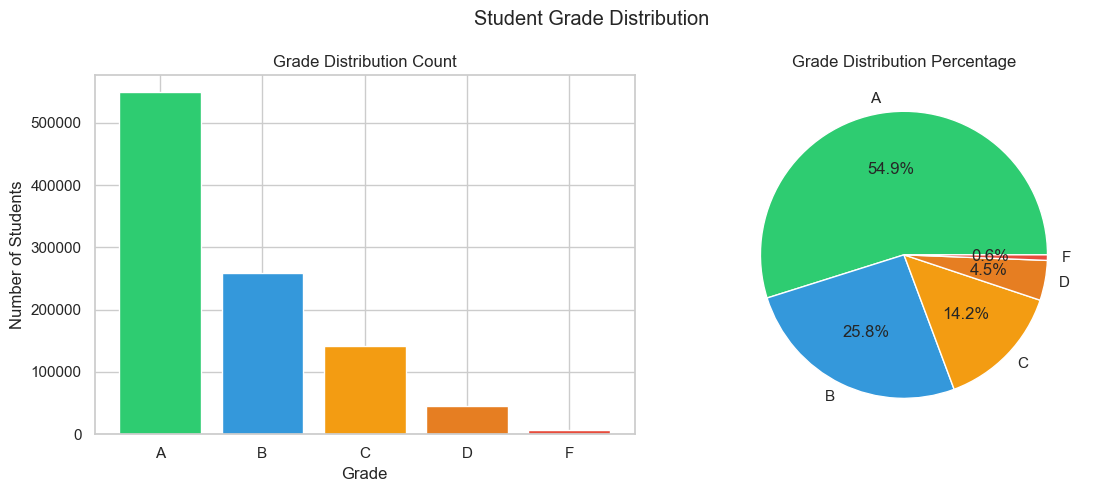

In [26]:
#Distribution of student grades

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
axes[0].bar(
    grade_counts.keys(),
    grade_counts.values(),
    color=grade_colors
)

axes[0].set_title("Grade Distribution Count")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Number of Students")

# Pie Chart
axes[1].pie(
    grade_counts.values(),
    labels=grade_counts.keys(),
    autopct='%1.1f%%',
    colors=grade_colors
)

axes[1].set_title("Grade Distribution Percentage")

# Main title
plt.suptitle("Student Grade Distribution")

plt.tight_layout()
plt.show()

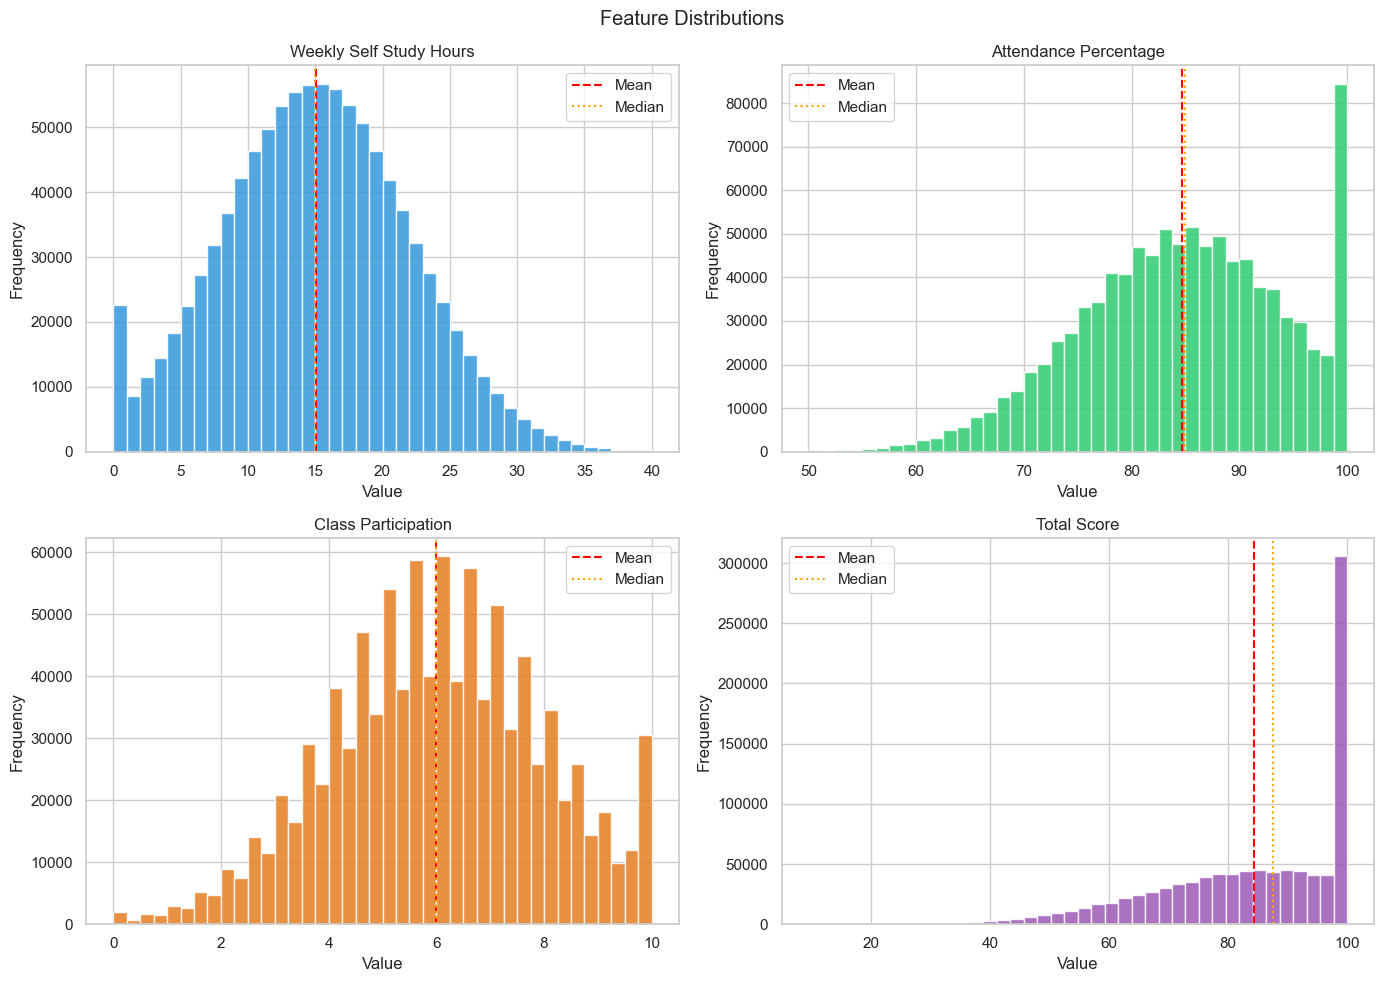

In [27]:
#Distribution of key features

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#3498DB', '#2ECC71', '#E67E22', '#9B59B6']

for i, feature in enumerate(feature_columns):

    # Histogram
    axes[i].hist(df[feature], bins=40, color=colors[i], alpha=0.85)

    # Mean line
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', label='Mean')

    # Median line
    axes[i].axvline(df[feature].median(), color='orange', linestyle=':', label='Median')

    axes[i].set_title(feature.replace('_', ' ').title())
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

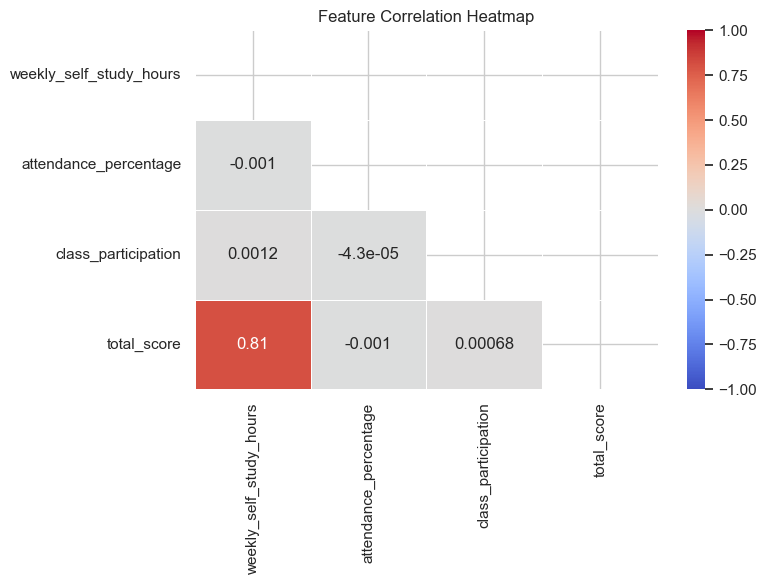

In [28]:
# correlation heatmap 
corr_df = df[feature_columns].corr()

plt.figure(figsize=(8, 6))

# Create a mask to hide upper triangle 
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(
    corr_df,
    annot=True,
    cmap='coolwarm',
    mask=mask,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

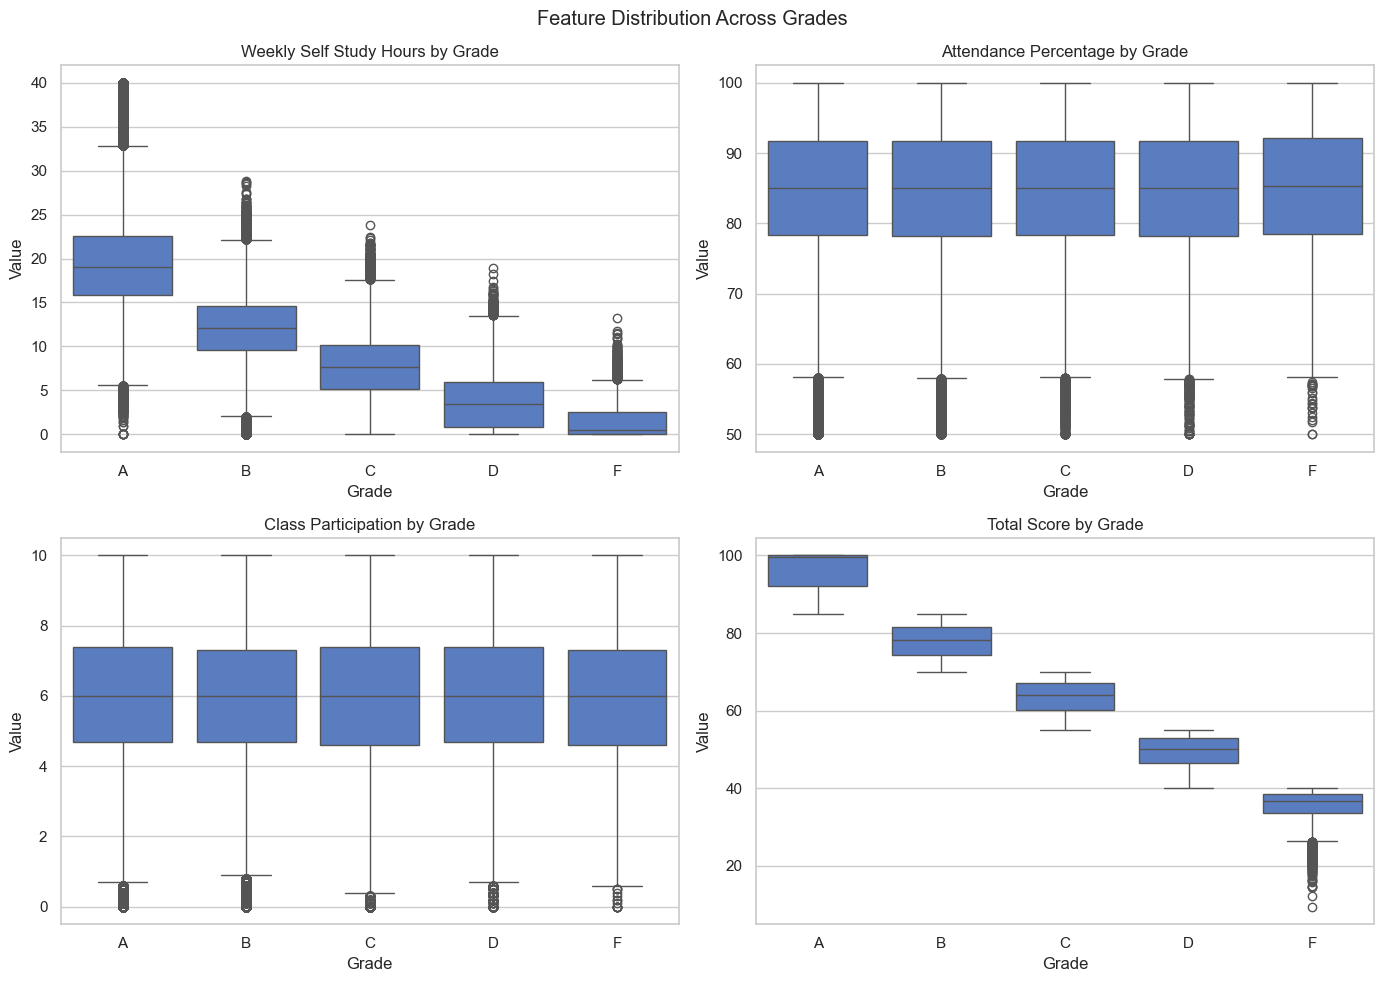

In [29]:
# Compare how each feature changes across different grades
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):

    sns.boxplot(
        data=df,
        x='grade',
        y=feature,
        order=grade_order,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature.replace('_', ' ').title()} by Grade")
    axes[i].set_xlabel("Grade")
    axes[i].set_ylabel("Value")

plt.suptitle("Feature Distribution Across Grades")
plt.tight_layout()
plt.show()

##  Data Preparation 

In [31]:
#Encoding
le = LabelEncoder()
df['grade_encoded'] = le.fit_transform(df[target_column])

encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Grade encoding map:", encoding_map)

print("\nClass distribution after encoding:")

for grade in le.classes_:
    code = encoding_map[grade]
    count = (df['grade_encoded'] == code).sum()
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)

    print(f"{grade} (code {code}): {count} students ({pct:.1f}%) {bar}")

Grade encoding map: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'F': np.int64(4)}

Class distribution after encoding:
A (code 0): 548644 students (54.9%) ███████████████████████████
B (code 1): 258174 students (25.8%) ████████████
C (code 2): 141980 students (14.2%) ███████
D (code 3): 44998 students (4.5%) ██
F (code 4): 6204 students (0.6%) 


In [33]:
print("Feature validation (range checks):")

validation_rules = {
    'weekly_self_study_hours': (0, 100),
    'attendance_percentage': (0, 100),
    'class_participation': (0, 10),
    'total_score': (0, 100)
}

all_valid = True

for feature, (min_val, max_val) in validation_rules.items():

    out_of_range = df[(df[feature] < min_val) | (df[feature] > max_val)]

    if len(out_of_range) > 0:
        print(f"{feature}: {len(out_of_range)} invalid values found")
        all_valid = False
        break

    print(f"{feature}: OK")

if all_valid:
    print("\nAll features passed validation")
else:
    print("\nValidation failed: check data before proceeding")

Feature validation (range checks):
weekly_self_study_hours: OK
attendance_percentage: OK
class_participation: OK
total_score: OK

All features passed validation


In [37]:
# Train-test split and scaling
X = df[feature_columns]
y = df["grade_encoded"]

#Train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state,
    stratify=y
)

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 800000
Test size: 200000


## Phase 4: Modeling


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TOPIC 5: SEPARATE COMPILATION / MODULAR FUNCTIONS         ║
# ║  Each model is wrapped in a reusable function (subroutine) ║
# ╚══════════════════════════════════════════════════════════════╝

def train_logistic_regression(X_tr: np.ndarray, y_tr,
                              X_te: np.ndarray, y_te) -> tuple:
    """
    Train and evaluate a Logistic Regression classifier.
    Returns: (model, predictions, accuracy)
    """
    model = LogisticRegression(max_iter=500, random_state=random_state)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc   = accuracy_score(y_te, preds)
    return model, preds, acc


def train_decision_tree(X_tr, y_tr, X_te, y_te) -> tuple:
    """
    Train and evaluate a Decision Tree classifier.
    Returns: (model, predictions, accuracy)
    """
    model = DecisionTreeClassifier(max_depth=8, random_state=random_state)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc   = accuracy_score(y_te, preds)
    return model, preds, acc


def train_random_forest(X_tr, y_tr, X_te, y_te,
                        params: dict) -> tuple:
    """
    Train and evaluate a Random Forest classifier.
    Returns: (model, predictions, accuracy)
    """
    model = RandomForestClassifier(**params)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc   = accuracy_score(y_te, preds)
    return model, preds, acc


# ── Train all three models (using subroutines above) ──
print('Training models...')
lr_model, lr_pred, lr_acc = train_logistic_regression(
    X_train_scaled, y_train, X_test_scaled, y_test)
print(f'  [1] Logistic Regression  →  Accuracy: {lr_acc*100:.2f}%')

dt_model, dt_pred, dt_acc = train_decision_tree(
    X_train, y_train, X_test, y_test)
print(f'  [2] Decision Tree        →  Accuracy: {dt_acc*100:.2f}%')

rf_model, rf_pred, rf_acc = train_random_forest(
    X_train, y_train, X_test, y_test, model_params)
print(f'  [3] Random Forest        →  Accuracy: {rf_acc*100:.2f}%')

# IF check against success criterion (Topic 3)
if rf_acc >= threshold:
    print(f'\n✅ SUCCESS: Random Forest accuracy ({rf_acc*100:.2f}%) meets the {threshold*100:.0f}% target.')
else:
    print(f'\n⚠ BELOW TARGET: {rf_acc*100:.2f}% < {threshold*100:.0f}%. Consider tuning hyperparameters.')

In [ ]:
# Accuracy comparison chart
model_names: list = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies: list  = [lr_acc, dt_acc, rf_acc]
bar_colors: list  = ['#3498DB', '#E67E22', '#2ECC71']

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accuracies, color=bar_colors, edgecolor='white', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f'{acc*100:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
            label=f'{threshold*100:.0f}% Success Target')
plt.ylim(0, 1.12)
plt.ylabel('Test-set Accuracy', fontsize=12)
plt.title('Figure 5: Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 5: Evaluation

> **Topic 1 – Error Analysis:** Precision, Recall, F1-score, and Cross-Validation quantify how well the model generalises.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TOPIC 1: ERROR ANALYSIS – Classification Report           ║
# ╚══════════════════════════════════════════════════════════════╝

grade_labels: np.ndarray = le.classes_

print('=' * 65)
print('  RANDOM FOREST – DETAILED CLASSIFICATION REPORT')
print('=' * 65)
print(classification_report(y_test, rf_pred, target_names=grade_labels))

In [ ]:
# Confusion matrices for Decision Tree vs Random Forest
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pred, name) in zip(axes,
        [(dt_pred, 'Decision Tree'), (rf_pred, 'Random Forest')]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=grade_labels).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Figure 6: Confusion Matrix – {name}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Feature Importance – horizontal bar chart
importances: np.ndarray = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_columns,
                      'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True).reset_index(drop=True)

fi_colors: list = ['#E74C3C' if v == fi_df['Importance'].max()
                   else '#3498DB' for v in fi_df['Importance']]

plt.figure(figsize=(9, 4))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'],
                color=fi_colors, edgecolor='white')
for bar, val in zip(bars, fi_df['Importance']):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold', fontsize=10)
plt.xlabel('Gini Importance Score')
plt.title('Figure 7: Feature Importance – Random Forest', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TOPIC 1: ERROR ANALYSIS – 5-Fold Cross-Validation         ║
# ╚══════════════════════════════════════════════════════════════╝

print('Running 5-fold cross-validation on Random Forest...')
cv_scores: np.ndarray = cross_val_score(
    rf_model, X, y, cv=n_folds, scoring='accuracy', n_jobs=-1)

print(f'\nCV Scores per fold : {np.round(cv_scores, 4)}')
print(f'Mean CV Accuracy   : {cv_scores.mean():.4f}  ({cv_scores.mean()*100:.2f}%)')
print(f'Std Deviation      : ± {cv_scores.std():.4f}')
print(f'95% Confidence Interval: [{cv_scores.mean()-2*cv_scores.std():.4f},'
      f' {cv_scores.mean()+2*cv_scores.std():.4f}]')

# Visualise CV results
plt.figure(figsize=(8, 4))
plt.bar([f'Fold {i+1}' for i in range(n_folds)], cv_scores,
        color='#2E75B6', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.3f}')
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Figure 8: 5-Fold Cross-Validation Accuracy', fontweight='bold', fontsize=13)
plt.legend(); plt.tight_layout()
plt.savefig('fig8_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Decision tree structure (depth=3 for clarity)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=random_state)
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(22, 9))
plot_tree(dt_viz, feature_names=feature_columns,
          class_names=grade_labels, filled=True,
          rounded=True, fontsize=10, impurity=True)
plt.title('Figure 9: Decision Tree Structure (max_depth = 3)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 6: Deployment

> **Topic 5 – Separate Compilation / Modular Code:** The `predict_grade()` function is a self-contained subroutine that can be imported into any script.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  TOPIC 4+5: SUBROUTINE – Modular Prediction Function       ║
# ╚══════════════════════════════════════════════════════════════╝

def predict_grade(weekly_study_hours: float,
                  attendance_pct: float,
                  participation_score: float,
                  total_score_val: float) -> dict:
    """
    Predict a student's final grade using the trained Random Forest model.

    Parameters
    ----------
    weekly_study_hours   : float – Hours studied per week (e.g. 15.0)
    attendance_pct       : float – Attendance % (0–100, e.g. 85.0)
    participation_score  : float – Class participation 1–10 (e.g. 6.0)
    total_score_val      : float – Cumulative assessment score 0–100

    Returns
    -------
    dict with keys: predicted_grade, confidence_%, all_probabilities_%
    """
    # Input validation using IF/ELIF/ELSE (Topic 3)
    if not (0 <= attendance_pct <= 100):
        raise ValueError('Attendance must be between 0 and 100.')
    elif not (0 <= participation_score <= 10):
        raise ValueError('Participation score must be between 0 and 10.')
    elif not (0 <= total_score_val <= 100):
        raise ValueError('Total score must be between 0 and 100.')
    elif weekly_study_hours < 0:
        raise ValueError('Weekly study hours cannot be negative.')

    # Build input array (NumPy ndarray – Topic 2+4)
    input_arr: np.ndarray = np.array([[weekly_study_hours,
                                       attendance_pct,
                                       participation_score,
                                       total_score_val]])
    input_df = pd.DataFrame(input_arr, columns=feature_columns)

    prediction    = rf_model.predict(input_df)[0]
    probabilities = rf_model.predict_proba(input_df)[0]

    grade: str = le.inverse_transform([prediction])[0]
    prob_dict: dict = {g: round(float(p) * 100, 1)
                       for g, p in zip(le.classes_, probabilities)}

    return {
        'predicted_grade':      grade,
        'confidence_%':         prob_dict[grade],
        'all_probabilities_%':  prob_dict,
        'grade_description':    grade_descriptions[grade]
    }


print('✅ predict_grade() function ready.')

In [ ]:
# Test with three student profiles
test_profiles: list = [
    ('High performer',    20.0, 96.0, 8.5, 95.0),
    ('Average student',   12.0, 75.0, 4.0, 72.0),
    ('At-risk student',    4.0, 45.0, 1.5, 35.0),
]

print('=' * 70)
print(f"  {'Profile':<22} {'Grade':<8} {'Confidence':<14} Description")
print('=' * 70)

for name, study, attend, part, score in test_profiles:  # FOR LOOP (Topic 3)
    result = predict_grade(study, attend, part, score)
    print(f"  {name:<22} {result['predicted_grade']:<8}"
          f" {result['confidence_%']:>5.1f}%       "
          f" {result['grade_description']}")

In [ ]:
# ============================================================
# Interactive User Input (run this cell in Jupyter)
# ============================================================
print('\n' + '='*55)
print('  🎓  STUDENT GRADE PREDICTOR – SMA 390')
print('='*55 + '\n')

try:
    study  = float(input('Enter weekly self-study hours (e.g. 15): '))
    attend = float(input('Enter attendance percentage  (e.g. 85): '))
    part   = float(input('Enter participation score 1-10 (e.g. 6): '))
    score  = float(input('Enter total score 0-100   (e.g. 78): '))

    result = predict_grade(study, attend, part, score)

    print('\n' + '-'*45)
    print(f"  Predicted Grade : {result['predicted_grade']}")
    print(f"  Description     : {result['grade_description']}")
    print(f"  Confidence      : {result['confidence_%']}%")
    print(f"  All Probabilities:")
    for g, p in result['all_probabilities_%'].items():
        bar = '█' * int(p // 5)
        print(f"    {g}: {bar:<20} {p:.1f}%")
    print('-'*45)

except ValueError as e:
    print(f'Input error: {e}')
    print('Please enter valid numeric values within the specified ranges.')

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
summary_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Test Accuracy (%)': [round(lr_acc*100, 2),
                          round(dt_acc*100, 2),
                          round(rf_acc*100, 2)],
    'Status': [
        '✅ Above target' if lr_acc >= threshold else '❌ Below target',
        '✅ Above target' if dt_acc >= threshold else '❌ Below target',
        '✅ Above target' if rf_acc >= threshold else '❌ Below target',
    ]
})

print('\n📊 FINAL RESULTS SUMMARY')
print(summary_df.to_string(index=False))
print(f"\n🏆 Best Model    : Random Forest ({rf_acc*100:.2f}%)")
print(f"📌 Top Feature   : {fi_df.iloc[-1]['Feature']}")
print(f"📌 CV Mean Acc   : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"\n✅ SMA 390 Group Project – System successfully deployed.")